<a href="https://colab.research.google.com/github/d-toups/workout-data-analysis/blob/main/workout_data_analysis_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workout Data Analysis: Gender & Age Differences in Fitness Preferences & Calorie Burn

**Objective**:  
Explore how workout preferences and calorie expenditure differ by gender and age group using exploratory data analysis.

**Business Value**:  
These insights can help fitness apps, gyms, and wellness platforms create more targeted programs and recommendations.

## 1. Project Overview

## Project Goal
Analyze workout preferences and calorie expenditure patterns across different genders and age groups using exploratory data analysis.

**Business Context**:  
Understanding demographic differences in fitness behavior can help gyms, fitness apps, and health companies create more personalized programs and marketing strategies.

## Key Questions
- What workout types are most popular among different genders?
- How does calorie burn vary by age group and workout type?
- Are there noticeable differences in behavior between males and females?

## Tech Stack
- Python (pandas, seaborn, matplotlib)
- Jupyter Notebook

## 2. Imports and Setup

In [ ]:
# Import functions
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.workout_data_analysis_eda_statistics import (
    load_dataset,
    clean_dataset,
    plot_workout_by_age_group,
    plot_cpm,
    stats,
    find_correlations,
    plot_rf_feature_importance,
    evaluate_workout_type_rf
)

from src.workout_data_analysis_modeling_01 import(
    model_top_features,
    run_xgboost_workout_type
)

# Import librabries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency, ttest_ind
import warnings; warnings.filterwarnings('ignore')

## 3. Data Loading and Cleaning

In [2]:
# Load and Clean the Dataset
df_raw = load_dataset("gym_members_exercise_tracking.csv")
df, df_male, df_female = clean_dataset(df_raw)

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Male samples: {len(df_male)}, Female samples: {len(df_female)}")


Final dataset shape after cleaning: (973, 12)
Dataset shape after cleaning: (973, 12)
Male samples: 511, Female samples: 462


## Specific cleaning actions taken were:
- Add Calories Per Minute feature to aid further analysis
- Filter out ambiguous "Other" entries for gender
- Bin ages into age groups for cohort analysis
- Confirm data cleaning by checking unique values of gender and workout type
- Notably, the dataset contained no records for individuals over age 59. Thus, a Seniors cohort could not be analyzed.

## 4. Key Visualizations

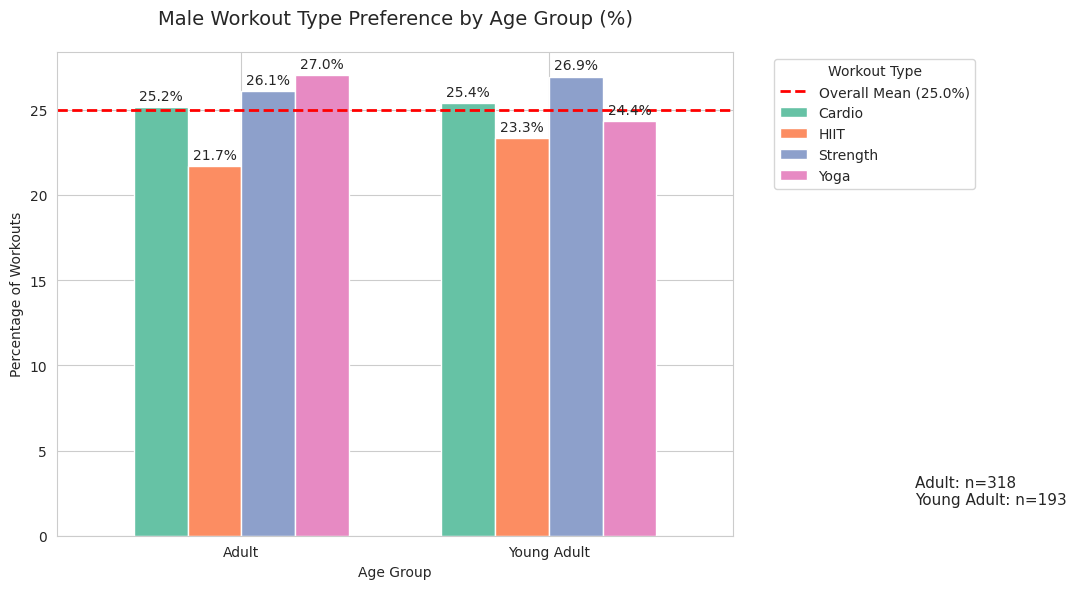

In [3]:
# 1. Plot Workout Preference by Age Group (Males)
plot_workout_by_age_group(df_male, 'Male')

**Male Workout Type Preferences**
- Adult males, surprisingly, show a preference for **Yoga**, though only slightly more than **Strength Training** and **Cardio**.
- Young Adults show a small preference for **Strength Training** as well as **Cardio**.
- The largest difference in preference between adult and young adult men is adults' 2.6% favorability of **Yoga**.
- Both groups favor **HIIT** least.

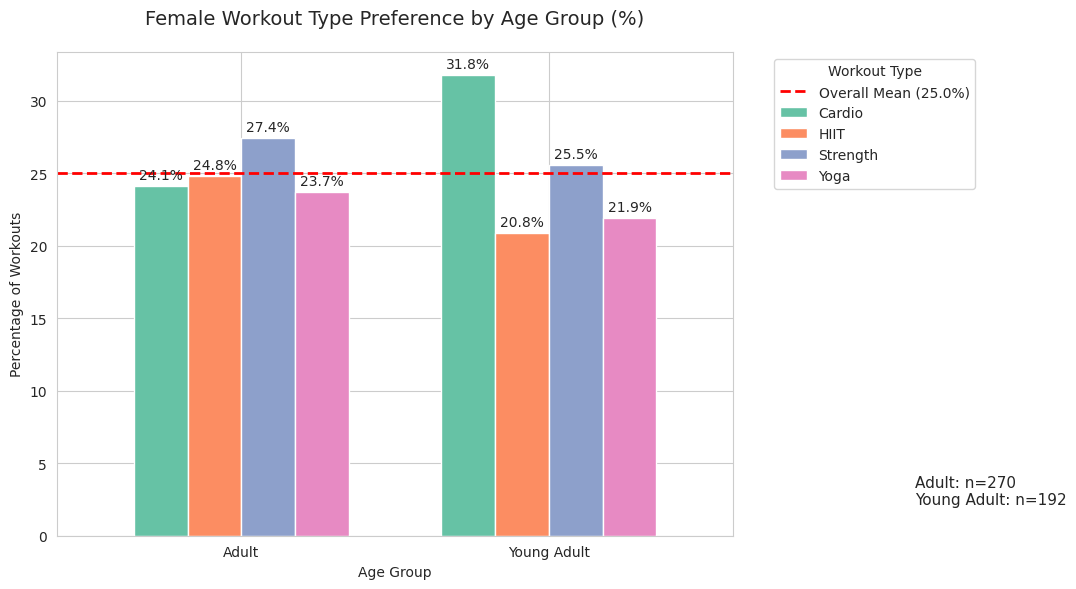

In [4]:
# 2. Plot Workout Preference by Age Group (Females)
plot_workout_by_age_group(df_female, 'Female')

**Female Workout Type Preferences**
- Adult females most strongly favor **Strength Training**.
- Young adult females prefer **Cardio** 6.3% above mean.
- Adult females least favor **Yoga**, while young adults prefer **HIIT** least.
- The largest difference between these groups is young adult females' 7.7% favorability of **Cardio** compared to adults.

**Overall Preference Insights**
- Both males and females consistently favor **Strength Training** and **Cardio** across both age groups, though adult men most prefer **Yoga**.
- The difference in workout preferences between genders is visible in both age groups, though the magnitude varies.

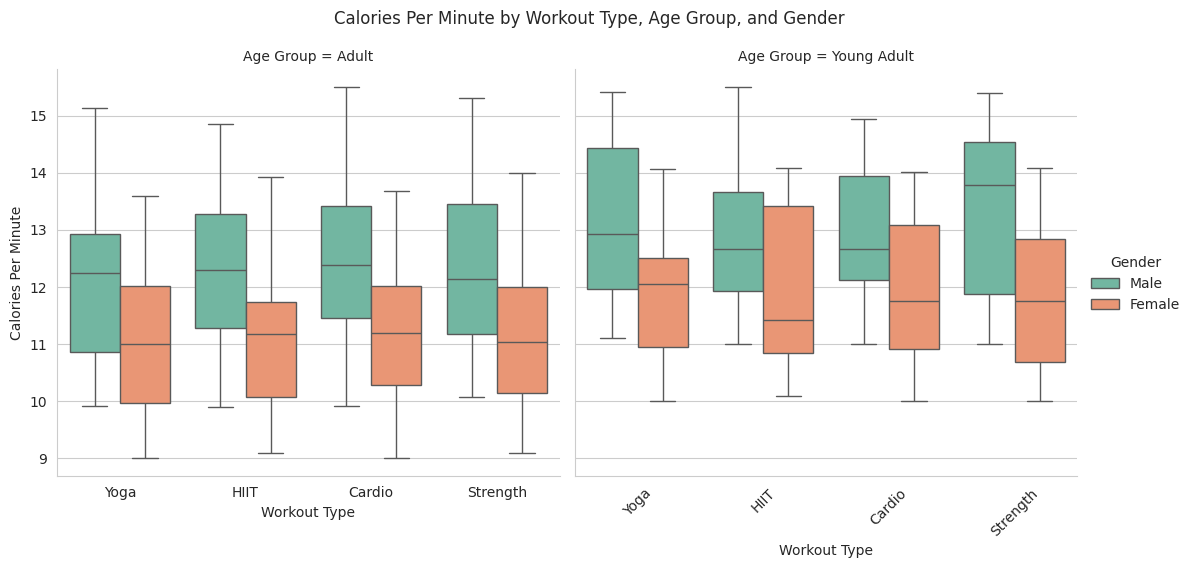

In [5]:
# 3. Plot Calories per Minute by Workout Type and Gender
plot_cpm(df)

**Intensity (Calories Per Minute)**
- **Young Adults** consistently perform higher intensity exercise in every category (as expected).
- **Young Adult males** tend to achieve the highest peak calorie burn rates, especially during Strength Training and Yoga.
- Females generally show more consistent (less variable) calorie burn across workout types compared to males, with exception of young adult female **HIIT** participants, who saw several high outliers.
- **Strength Training** exhibits the highest variability in intensity among males.

## 4. Statistical Analysis

In [6]:
## Conduct chi-square and t-testing on dataset
stats(df)


--------- Chi square tests  ---------

Age Group: Adult (588 samples)
   Chi-square p-value: 0.7021 → Not significant
   Contingency Table:
Workout Type  Cardio  HIIT  Strength  Yoga
Gender                                    
Female            65    67        74    64
Male              80    69        83    86
Age Group: Young Adult (385 samples)
   Chi-square p-value: 0.5785 → Not significant
   Contingency Table:
Workout Type  Cardio  HIIT  Strength  Yoga
Gender                                    
Female            61    40        49    42
Male              49    45        52    47

--------- T-tests by age group within each gender ---------

Male | Age (511 total samples)
   Young Adult : n=193, Mean = 25.82
   Adult       : n=318, Mean = 46.99
   p-value     : 0.0000 → Significant difference

Male | Avg Bpm (511 total samples)
   Young Adult : n=193, Mean = 142.57
   Adult       : n=318, Mean = 144.70
   p-value     : 0.1031 → No significant difference

Male | Calories Burned (511

## Statistical Analysis

### 1. Chi-Square Test of Independence
- **Workout Type vs Gender**: p = 0.7021 (Adults), p = 0.5785 (Young Adults)  
  → No statistically significant association between gender and workout type preference.

- **Workout Type vs Age Group**: (results from test)

### 2. Independent T-Tests (Calories Per Minute)
- **Young Adult vs Adult Males**: p < 0.001 (highly significant)
- **Young Adult vs Adult Females**: p < 0.001 (highly significant)

**Conclusion**: Age group has a strong, statistically significant effect on training intensity (Calories Per Minute), while gender does not significantly influence workout type preference.

### 3. Additional Insights
- Young adults consistently train at higher intensity than adults across both genders.
- The lack of significant gender differences in workout type preference suggests that fitness preferences are more individualized than gender-stereotyped.

## Correlation

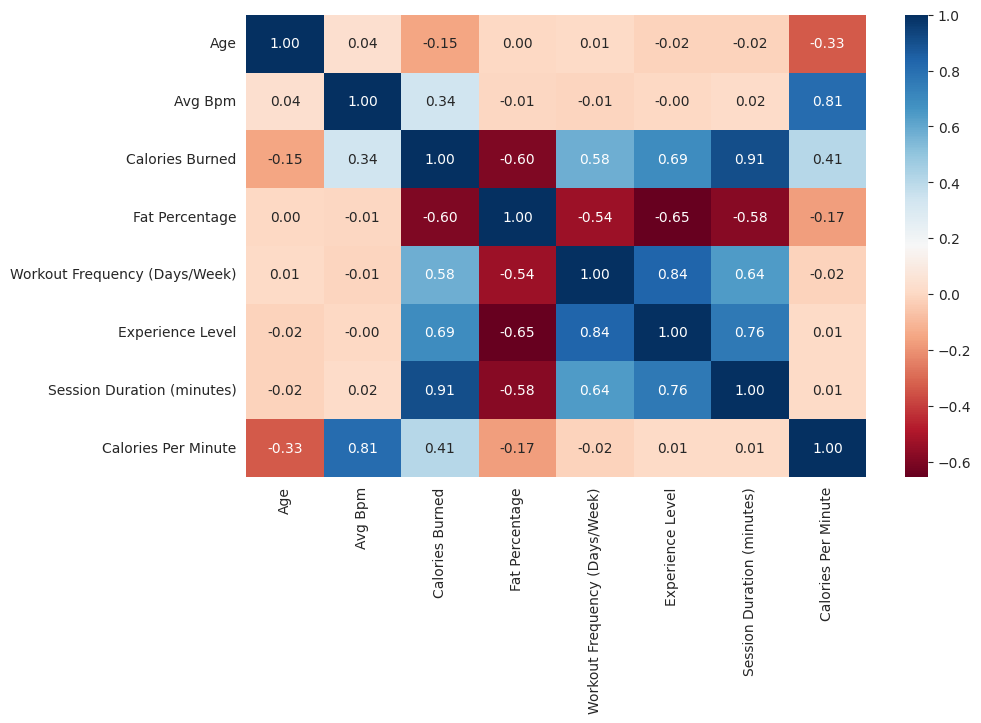

In [7]:
find_correlations(df)

## Correlation Analysis

A correlation heatmap was generated to identify relationships between numerical features.

### Key Observations:
- **Calories Per Minute** shows moderate positive correlation with **Average BPM** and **Session Duration**, as expected for intensity metrics.
- **Fat Percentage** is moderately correlated with **Calories Per Minute**, suggesting body composition influences training intensity.
- **Age** has a noticeable negative correlation with training intensity metrics, supporting the finding that younger individuals tend to train at higher intensity.
- **Workout Frequency** shows weak correlations with most other variables, indicating it may be driven by external factors not captured in this dataset.

**Insight**: The strongest relationships revolve around training intensity (CPM, BPM, Duration). This reinforces that physiological effort, rather than demographic factors alone, is the primary driver in the data.

## Feature Importance

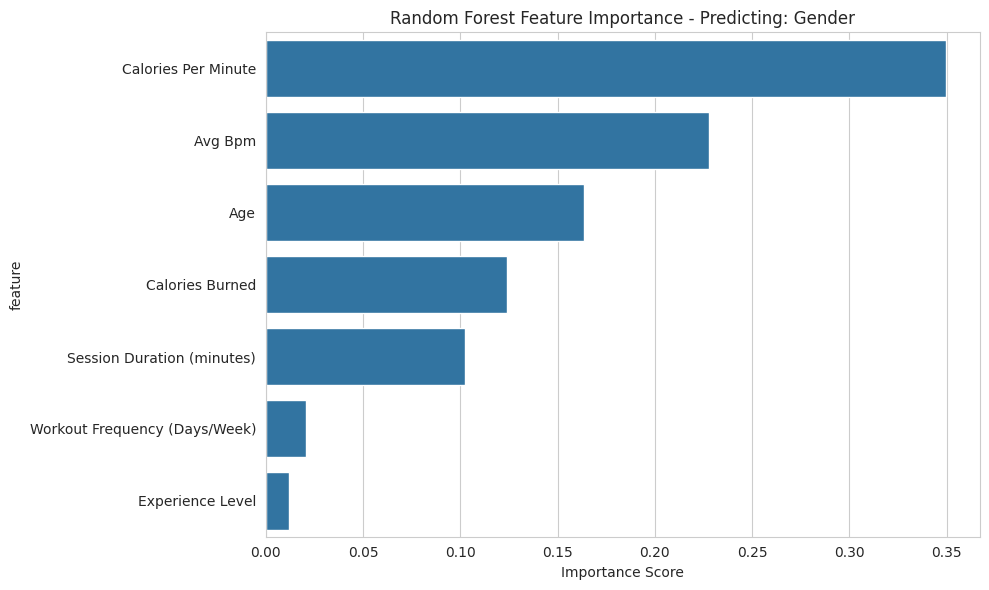


Top 5 features for predicting 'Gender':
                      feature  importance
6         Calories Per Minute    0.349698
1                     Avg Bpm    0.227840
0                         Age    0.163366
2             Calories Burned    0.124168
5  Session Duration (minutes)    0.102343


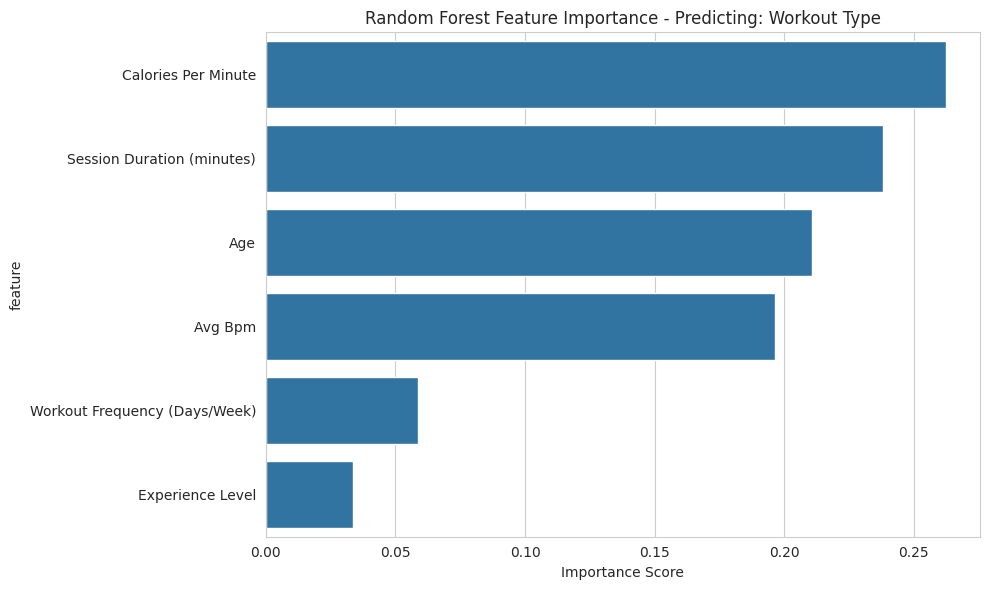


Top 5 features for predicting 'Workout Type':
                         feature  importance
5            Calories Per Minute    0.262392
4     Session Duration (minutes)    0.238142
0                            Age    0.210827
1                        Avg Bpm    0.196495
2  Workout Frequency (Days/Week)    0.058577


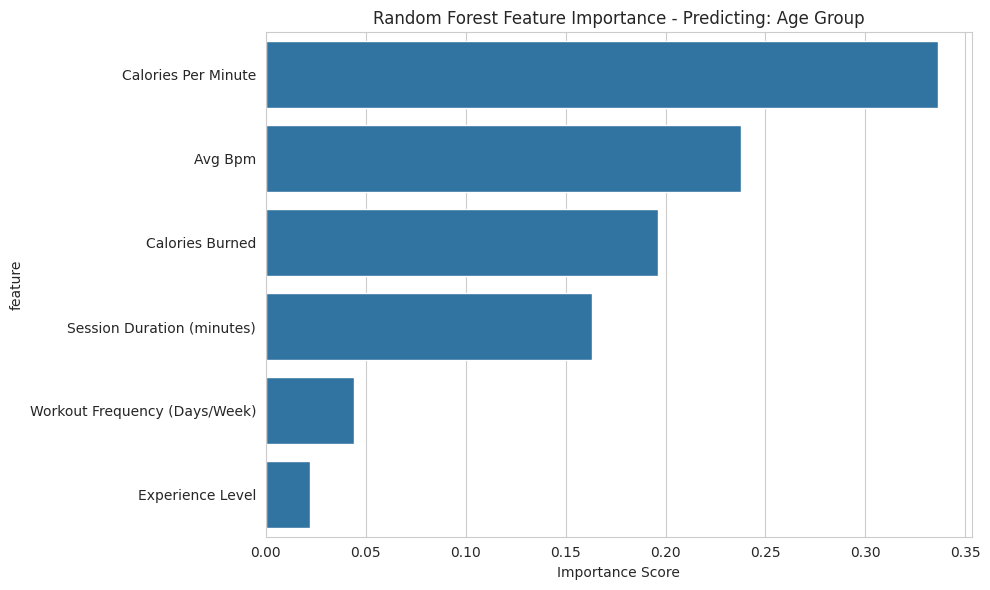


Top 5 features for predicting 'Age Group':
                         feature  importance
5            Calories Per Minute    0.336490
0                        Avg Bpm    0.237566
1                Calories Burned    0.196211
4     Session Duration (minutes)    0.163317
2  Workout Frequency (Days/Week)    0.044152


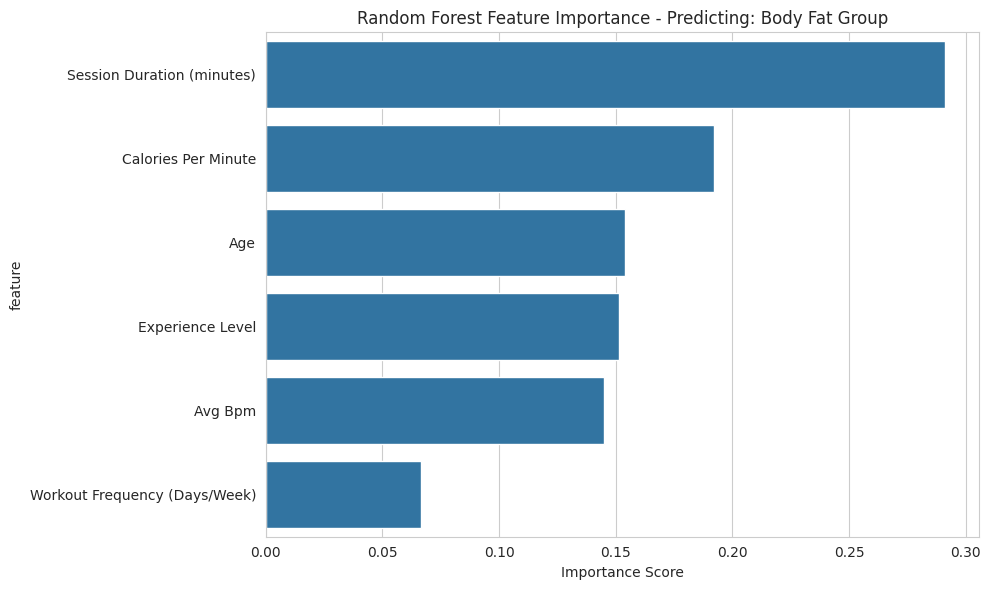


Top 5 features for predicting 'Body Fat Group':
                      feature  importance
4  Session Duration (minutes)    0.291097
5         Calories Per Minute    0.192207
0                         Age    0.154011
3            Experience Level    0.151169
1                     Avg Bpm    0.144945


In [8]:
plot_rf_feature_importance(df)

## Feature Importance Analysis

A Random Forest model was trained to predict Workout Type Preference. The top contributing features were:

- **Calories Per Minute** — strongest predictor, highlighting training intensity as key to workout choice
- **Session Duration** — longer sessions strongly associated with certain workout types
- **Fat Percentage** — body composition plays a notable role
- **Age** and **Average BPM** — demographic and physiological factors

**Observation**: The dominance of intensity-related features (CPM, Duration, BPM) suggests that **how** someone trains is more predictive of workout type than demographic factors alone.

## Modeling Attempts

1. Random Forest Classifier

In [12]:
evaluate_workout_type_rf

<function src.workout_data_analysis_eda_statistics.evaluate_workout_type_rf(df, target_col='Workout Type', random_state=42)>

2. XGBoost

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV Accuracy: 0.2803

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.45      0.39        51
           1       0.21      0.14      0.17        44
           2       0.27      0.27      0.27        52
           3       0.33      0.33      0.33        48

    accuracy                           0.30       195
   macro avg       0.29      0.30      0.29       195
weighted avg       0.29      0.30      0.29       195



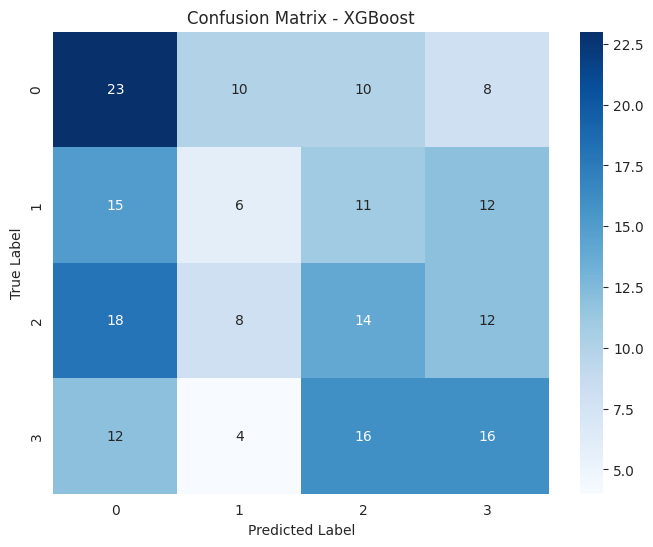

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
run_xgboost_workout_type(df)

## Modeling Attempts

Multiple classifiers (Random Forest and XGBoost) were evaluated to predict Workout Type Preference using the top features.

**Results**:
- Best accuracy achieved: ~27-29%
- Performance was only marginally better than random guessing (25% for 4 classes)

**Observation**: The low predictive performance indicates that while clear visual and statistical patterns exist in the data, the current features do not contain sufficient signal to reliably classify an individual's preferred workout type. This is common in behavioral datasets where individual preference has high variability.

## Conclusions & Key Learnings

- Clear visual preferences exist, but they are not strongly statistically significant by gender.
- Age is a much stronger driver of training intensity than gender.
- Predicting specific workout type preference proved challenging (accuracy ~28%), suggesting that additional features (motivation, goals, previous experience, etc.) would be needed for better prediction.

**Business Insight**: Fitness platforms should prioritize **age-based intensity recommendations** and use softer, preference-based suggestions for workout types rather than hard rules.